# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members

* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu


# 07 Results Synthesis

This notebook aggregates and synthesizes results from the ablation study (Notebook 04) and external evaluation (Notebook 06) to produce final comparison tables for reporting and presentation.

## Purpose

The goal of this notebook is to consolidate experiment outputs into a single, analysis-ready dataset that supports the final project deliverables.

Specifically, this notebook:

- Loads internal validation results from the ablation study (ISIC 2019)
- Loads external evaluation results from MILK10K
- Aligns backbone and phase identifiers across both result sets
- Merges results into a unified comparison table
- Computes derived metrics:
  - Change in balanced accuracy (ΔBACC) relative to baseline
  - Generalization gap between ISIC and MILK10K performance
- Saves a clean, report-ready results table

This notebook does not perform any training or inference. It operates only on previously saved outputs to ensure reproducibility and separation between experiment generation and result analysis.

## Data Sources

This notebook uses the following precomputed outputs:

- `ablation_full_comparison.csv`
  - Generated in Notebook 04
  - Contains ISIC 2019 validation performance across all backbones and augmentation phases

- `06_step_b_full_comparison.csv`
  - Generated in Notebook 06
  - Contains MILK10K external evaluation performance using trained checkpoints

These files serve as the authoritative record of experimental results for this project.

## Setup

This section initializes paths and verifies that required result files from previous notebooks are available.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
# Resolve project root (same pattern as other notebooks)
PROJECT_ROOT = Path.cwd().resolve().parents[0]

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# --- Robust file finder (no hardcoded paths) ---
def find_one_csv(filename, base_dir=OUTPUTS_DIR):
    matches = sorted(base_dir.rglob(filename))
    
    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} NOT FOUND under {base_dir}. "
            "Run Notebook 04 and 06 or verify outputs exist on this machine."
        )
    
    if len(matches) > 1:
        print(f"Multiple matches found for {filename}, using first:")
        for m in matches:
            print("  ", m.relative_to(PROJECT_ROOT))
    
    return matches[0]

# Locate required files (NO assumptions about folder structure)
ABLATION_PATH = find_one_csv("ablation_full_comparison.csv")
EXTERNAL_PATH = find_one_csv("06_step_b_full_comparison.csv")

# Output directory
SYNTHESIS_DIR = OUTPUTS_DIR / "reports" / "07_results_synthesis"
SYNTHESIS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_TABLE_PATH = SYNTHESIS_DIR / "final_results_table.csv"

print("Resolved paths:")
print("  ABLATION_PATH:", ABLATION_PATH)
print("  EXTERNAL_PATH:", EXTERNAL_PATH)

Resolved paths:
  ABLATION_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_full_comparison.csv
  EXTERNAL_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_step_b_full_comparison.csv


In [3]:
print("Checking required input files...\n")

for path in [ABLATION_PATH, EXTERNAL_PATH]:
    if path.exists():
        print(f"FOUND: {path}")
    else:
        raise FileNotFoundError(f"MISSING: {path}")

Checking required input files...

FOUND: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_full_comparison.csv
FOUND: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_step_b_full_comparison.csv


In [4]:
ablation_df = pd.read_csv(ABLATION_PATH)
external_df = pd.read_csv(EXTERNAL_PATH)

print("Ablation shape:", ablation_df.shape)
print("External shape:", external_df.shape)

display(ablation_df.head())
display(external_df.head())

Ablation shape: (12, 25)
External shape: (12, 29)


,backbone,stage,epochs_requested,train_size,combined_train_size,val_size,active_phases,augmentation_mode,use_cutmix,best_epoch,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,resnet50,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,5,...,0.930959,0.972665,0.905116,0.944488,0.954559,0.997391,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,resnet50,phase1_plus_2,5,21531,21531,3800,phase1+phase2,on_the_fly_cumulative_transform,False,5,...,0.931320,0.992244,0.891334,0.946635,0.965232,0.997901,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,5,21531,21531,3800,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,5,...,0.928634,0.992081,0.887064,0.947042,0.952963,0.991907,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,resnet50,phase1_plus_2_plus_3_plus_4,5,21531,21531,3800,phase1+phase2+phase3+phase4,on_the_fly_cumulative_transform,True,5,...,0.913339,0.962053,0.893868,0.935338,0.968920,0.995803,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,efficientnet_b0,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,4,...,0.926541,0.993520,0.914086,0.948779,0.966058,0.999496,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


,backbone,stage,stage_order,checkpoint_path,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,...,bacc_generalization_gap,inference_elapsed_hms,delta_isic_val_bacc_from_prev,delta_milk_lesion_bacc_from_prev,delta_bacc_gap_from_prev,bacc_gap_narrowing_from_prev,delta_isic_val_macro_auc_from_prev,delta_milk_lesion_macro_auc_from_prev,delta_auc_gap_from_prev,auc_gap_narrowing_from_prev
0,densenet121,baseline,0,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.847488,0.484983,0.956321,0.741612,...,0.256629,0:51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,densenet121,phase1_plus_2,1,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.866462,0.542317,0.955013,0.736727,...,0.194409,0:52,-0.004885,0.057334,-0.062219,0.062219,-0.001309,0.018974,-0.020282,0.020282
2,densenet121,phase1_plus_2_plus_3,2,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.859764,0.516261,0.952876,0.712059,...,0.195798,0:54,-0.024667,-0.026056,0.001389,-0.001389,-0.002137,-0.006698,0.004561,-0.004561
3,densenet121,phase1_plus_2_plus_3_plus_4,3,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.846213,0.440994,0.939823,0.697137,...,0.256143,0:52,-0.014922,-0.075268,0.060345,-0.060345,-0.013053,-0.013552,0.000499,-0.000499
4,efficientnet_b0,baseline,0,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.860853,0.528719,0.963139,0.770305,...,0.241586,0:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
STAGE_ORDER = {
    "baseline": 0,
    "phase1_plus_2": 1,
    "phase1_plus_2_plus_3": 2,
    "phase1_plus_2_plus_3_plus_4": 3,
}

STAGE_LABELS = {
    "baseline": "Phase 1",
    "phase1_plus_2": "Phase 1+2",
    "phase1_plus_2_plus_3": "Phase 1+2+3",
    "phase1_plus_2_plus_3_plus_4": "Phase 1+2+3+4",
}

BACKBONE_LABELS = {
    "resnet50": "ResNet-50",
    "efficientnet_b0": "EfficientNet-B0",
    "densenet121": "DenseNet-121",
}

In [6]:
internal_results = ablation_df.copy()

internal_results["stage_order"] = internal_results["stage"].map(STAGE_ORDER)
internal_results["stage_label"] = internal_results["stage"].map(STAGE_LABELS)
internal_results["backbone_label"] = internal_results["backbone"].map(BACKBONE_LABELS)

internal_results = internal_results[
    [
        "backbone",
        "backbone_label",
        "stage",
        "stage_order",
        "stage_label",
        "best_val_balanced_accuracy",
        "best_val_macro_auc",
    ]
].rename(
    columns={
        "best_val_balanced_accuracy": "isic_val_bacc",
        "best_val_macro_auc": "isic_val_macro_auc",
    }
)

internal_results = internal_results.sort_values(["backbone", "stage_order"]).reset_index(drop=True)

display(internal_results)

,backbone,backbone_label,stage,stage_order,stage_label,isic_val_bacc,isic_val_macro_auc
0,densenet121,DenseNet-121,baseline,0,Phase 1,0.741612,0.956321
1,densenet121,DenseNet-121,phase1_plus_2,1,Phase 1+2,0.736727,0.955013
2,densenet121,DenseNet-121,phase1_plus_2_plus_3,2,Phase 1+2+3,0.712059,0.952876
3,densenet121,DenseNet-121,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.697137,0.939823
4,efficientnet_b0,EfficientNet-B0,baseline,0,Phase 1,0.770305,0.963139
5,efficientnet_b0,EfficientNet-B0,phase1_plus_2,1,Phase 1+2,0.774282,0.962638
6,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3,2,Phase 1+2+3,0.758831,0.960091
7,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.726747,0.942897
8,resnet50,ResNet-50,baseline,0,Phase 1,0.701634,0.955856
9,resnet50,ResNet-50,phase1_plus_2,1,Phase 1+2,0.747590,0.959299


In [7]:
external_results = external_df.copy()

external_results["stage_order"] = external_results["stage"].map(STAGE_ORDER)
external_results["stage_label"] = external_results["stage"].map(STAGE_LABELS)
external_results["backbone_label"] = external_results["backbone"].map(BACKBONE_LABELS)

external_results = external_results[
    [
        "backbone",
        "backbone_label",
        "stage",
        "stage_order",
        "stage_label",
        "milk_lesion_bacc",
        "milk_lesion_macro_auc",
    ]
]

external_results = external_results.sort_values(["backbone", "stage_order"]).reset_index(drop=True)

display(external_results)

,backbone,backbone_label,stage,stage_order,stage_label,milk_lesion_bacc,milk_lesion_macro_auc
0,densenet121,DenseNet-121,baseline,0,Phase 1,0.484983,0.847488
1,densenet121,DenseNet-121,phase1_plus_2,1,Phase 1+2,0.542317,0.866462
2,densenet121,DenseNet-121,phase1_plus_2_plus_3,2,Phase 1+2+3,0.516261,0.859764
3,densenet121,DenseNet-121,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.440994,0.846213
4,efficientnet_b0,EfficientNet-B0,baseline,0,Phase 1,0.528719,0.860853
5,efficientnet_b0,EfficientNet-B0,phase1_plus_2,1,Phase 1+2,0.532565,0.866326
6,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3,2,Phase 1+2+3,0.571480,0.881142
7,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.515758,0.861043
8,resnet50,ResNet-50,baseline,0,Phase 1,0.437035,0.819352
9,resnet50,ResNet-50,phase1_plus_2,1,Phase 1+2,0.480939,0.834669


In [8]:
final_results = internal_results.merge(
    external_results,
    on=["backbone", "backbone_label", "stage", "stage_order", "stage_label"],
    how="inner",
    validate="one_to_one",
)

final_results = final_results.sort_values(["backbone", "stage_order"]).reset_index(drop=True)

print("Final results shape:", final_results.shape)
display(final_results)

Final results shape: (12, 9)


,backbone,backbone_label,stage,stage_order,stage_label,isic_val_bacc,isic_val_macro_auc,milk_lesion_bacc,milk_lesion_macro_auc
0,densenet121,DenseNet-121,baseline,0,Phase 1,0.741612,0.956321,0.484983,0.847488
1,densenet121,DenseNet-121,phase1_plus_2,1,Phase 1+2,0.736727,0.955013,0.542317,0.866462
2,densenet121,DenseNet-121,phase1_plus_2_plus_3,2,Phase 1+2+3,0.712059,0.952876,0.516261,0.859764
3,densenet121,DenseNet-121,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.697137,0.939823,0.440994,0.846213
4,efficientnet_b0,EfficientNet-B0,baseline,0,Phase 1,0.770305,0.963139,0.528719,0.860853
5,efficientnet_b0,EfficientNet-B0,phase1_plus_2,1,Phase 1+2,0.774282,0.962638,0.532565,0.866326
6,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3,2,Phase 1+2+3,0.758831,0.960091,0.571480,0.881142
7,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.726747,0.942897,0.515758,0.861043
8,resnet50,ResNet-50,baseline,0,Phase 1,0.701634,0.955856,0.437035,0.819352
9,resnet50,ResNet-50,phase1_plus_2,1,Phase 1+2,0.747590,0.959299,0.480939,0.834669


In [9]:
final_results["delta_isic_bacc_from_baseline"] = (
    final_results["isic_val_bacc"]
    - final_results.groupby("backbone")["isic_val_bacc"].transform("first")
)

final_results["delta_milk_bacc_from_baseline"] = (
    final_results["milk_lesion_bacc"]
    - final_results.groupby("backbone")["milk_lesion_bacc"].transform("first")
)

final_results["generalization_gap_bacc"] = (
    final_results["isic_val_bacc"] - final_results["milk_lesion_bacc"]
)

display(final_results)

,backbone,backbone_label,stage,stage_order,stage_label,isic_val_bacc,isic_val_macro_auc,milk_lesion_bacc,milk_lesion_macro_auc,delta_isic_bacc_from_baseline,delta_milk_bacc_from_baseline,generalization_gap_bacc
0,densenet121,DenseNet-121,baseline,0,Phase 1,0.741612,0.956321,0.484983,0.847488,0.000000,0.000000,0.256629
1,densenet121,DenseNet-121,phase1_plus_2,1,Phase 1+2,0.736727,0.955013,0.542317,0.866462,-0.004885,0.057334,0.194409
2,densenet121,DenseNet-121,phase1_plus_2_plus_3,2,Phase 1+2+3,0.712059,0.952876,0.516261,0.859764,-0.029553,0.031278,0.195798
3,densenet121,DenseNet-121,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.697137,0.939823,0.440994,0.846213,-0.044475,-0.043989,0.256143
4,efficientnet_b0,EfficientNet-B0,baseline,0,Phase 1,0.770305,0.963139,0.528719,0.860853,0.000000,0.000000,0.241586
5,efficientnet_b0,EfficientNet-B0,phase1_plus_2,1,Phase 1+2,0.774282,0.962638,0.532565,0.866326,0.003977,0.003846,0.241717
6,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3,2,Phase 1+2+3,0.758831,0.960091,0.571480,0.881142,-0.011474,0.042761,0.187351
7,efficientnet_b0,EfficientNet-B0,phase1_plus_2_plus_3_plus_4,3,Phase 1+2+3+4,0.726747,0.942897,0.515758,0.861043,-0.043558,-0.012961,0.210990
8,resnet50,ResNet-50,baseline,0,Phase 1,0.701634,0.955856,0.437035,0.819352,0.000000,0.000000,0.264599
9,resnet50,ResNet-50,phase1_plus_2,1,Phase 1+2,0.747590,0.959299,0.480939,0.834669,0.045955,0.043903,0.266651


In [10]:
expected_runs = len(BACKBONE_LABELS) * len(STAGE_ORDER)

actual_runs = final_results.shape[0]

print(f"Expected runs: {expected_runs}")
print(f"Actual merged runs: {actual_runs}")

if actual_runs != expected_runs:
    raise ValueError(
        f"Expected {expected_runs} merged runs, but found {actual_runs}. "
        "Check backbone/stage alignment between Notebook 04 and Notebook 06 outputs."
    )

coverage = final_results.groupby("backbone_label")["stage"].nunique()
display(coverage)

if not (coverage == len(STAGE_ORDER)).all():
    raise ValueError("At least one backbone is missing one or more augmentation stages.")

print("Coverage check passed.")

Expected runs: 12
Actual merged runs: 12


backbone_label
DenseNet-121       4
EfficientNet-B0    4
ResNet-50          4
Name: stage, dtype: int64

Coverage check passed.


In [11]:
final_results_path = SYNTHESIS_DIR / "final_results_table.csv"

final_results.to_csv(final_results_path, index=False)

print(f"Saved final results table to:\n{final_results_path}")

Saved final results table to:
/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/reports/07_results_synthesis/final_results_table.csv


## Load Final Comparison Results

This section loads the final comparison table produced in Notebook 06, which already contains both internal (ISIC) and external (MILK10K) evaluation metrics.

In [12]:
FINAL_COMPARISON_PATH = OUTPUTS_DIR / "metrics" / "06_step_b_full_comparison.csv"

df = pd.read_csv(FINAL_COMPARISON_PATH)

print(df.shape)
display(df.head())

(12, 29)


,backbone,stage,stage_order,checkpoint_path,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,...,bacc_generalization_gap,inference_elapsed_hms,delta_isic_val_bacc_from_prev,delta_milk_lesion_bacc_from_prev,delta_bacc_gap_from_prev,bacc_gap_narrowing_from_prev,delta_isic_val_macro_auc_from_prev,delta_milk_lesion_macro_auc_from_prev,delta_auc_gap_from_prev,auc_gap_narrowing_from_prev
0,densenet121,baseline,0,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.847488,0.484983,0.956321,0.741612,...,0.256629,0:51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,densenet121,phase1_plus_2,1,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.866462,0.542317,0.955013,0.736727,...,0.194409,0:52,-0.004885,0.057334,-0.062219,0.062219,-0.001309,0.018974,-0.020282,0.020282
2,densenet121,phase1_plus_2_plus_3,2,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.859764,0.516261,0.952876,0.712059,...,0.195798,0:54,-0.024667,-0.026056,0.001389,-0.001389,-0.002137,-0.006698,0.004561,-0.004561
3,densenet121,phase1_plus_2_plus_3_plus_4,3,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.846213,0.440994,0.939823,0.697137,...,0.256143,0:52,-0.014922,-0.075268,0.060345,-0.060345,-0.013053,-0.013552,0.000499,-0.000499
4,efficientnet_b0,baseline,0,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,10274,5137,0.860853,0.528719,0.963139,0.770305,...,0.241586,0:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Figure 1: Internal vs External Performance Across Augmentation Stages

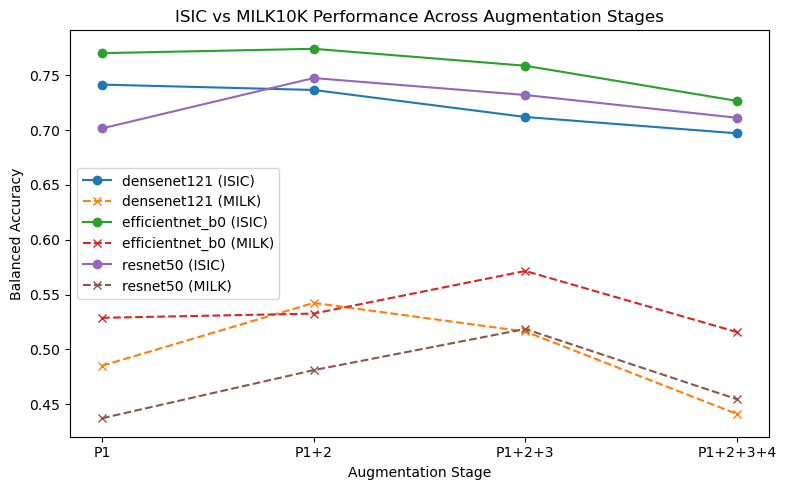

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

for backbone in df["backbone"].unique():
    sub = df[df["backbone"] == backbone].sort_values("stage_order")
    
    ax.plot(sub["stage_order"], sub["isic_val_bacc"], marker='o', label=f"{backbone} (ISIC)")
    ax.plot(sub["stage_order"], sub["milk_lesion_bacc"], marker='x', linestyle='--', label=f"{backbone} (MILK)")

ax.set_xlabel("Augmentation Stage")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("ISIC vs MILK10K Performance Across Augmentation Stages")

ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["P1", "P1+2", "P1+2+3", "P1+2+3+4"])

ax.legend()
plt.tight_layout()
plt.show()

## Figure 2: Generalization Gap (ISIC - MILK10K)

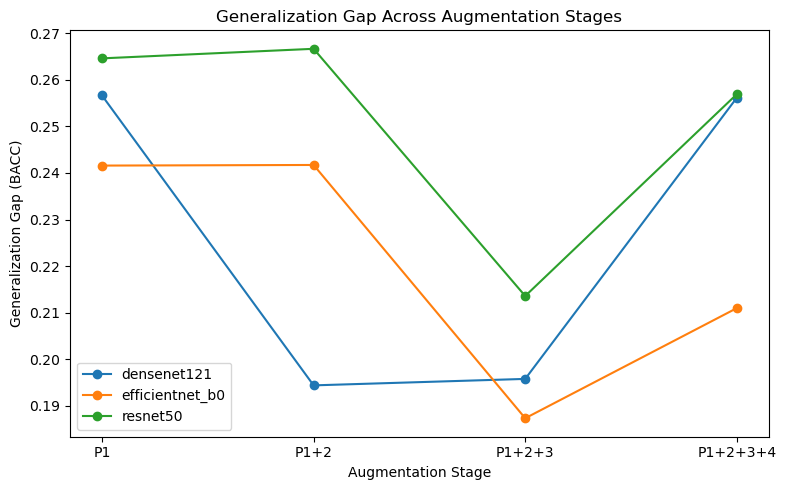

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

for backbone in df["backbone"].unique():
    sub = df[df["backbone"] == backbone].sort_values("stage_order")
    
    ax.plot(sub["stage_order"], sub["bacc_generalization_gap"], marker='o', label=backbone)

ax.set_xlabel("Augmentation Stage")
ax.set_ylabel("Generalization Gap (BACC)")
ax.set_title("Generalization Gap Across Augmentation Stages")

ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["P1", "P1+2", "P1+2+3", "P1+2+3+4"])

ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# --- load final results for report use ---

df = pd.read_csv(OUTPUTS_DIR / "metrics" / "06_step_b_full_comparison.csv")

view = df[
    [
        "backbone",
        "stage",
        "stage_order",
        "isic_val_bacc",
        "milk_lesion_bacc",
        "bacc_generalization_gap",
    ]
].sort_values(["backbone", "stage_order"])

display(view)

,backbone,stage,stage_order,isic_val_bacc,milk_lesion_bacc,bacc_generalization_gap
0,densenet121,baseline,0,0.741612,0.484983,0.256629
1,densenet121,phase1_plus_2,1,0.736727,0.542317,0.194409
2,densenet121,phase1_plus_2_plus_3,2,0.712059,0.516261,0.195798
3,densenet121,phase1_plus_2_plus_3_plus_4,3,0.697137,0.440994,0.256143
4,efficientnet_b0,baseline,0,0.770305,0.528719,0.241586
5,efficientnet_b0,phase1_plus_2,1,0.774282,0.532565,0.241717
6,efficientnet_b0,phase1_plus_2_plus_3,2,0.758831,0.571480,0.187351
7,efficientnet_b0,phase1_plus_2_plus_3_plus_4,3,0.726747,0.515758,0.210990
8,resnet50,baseline,0,0.701634,0.437035,0.264599
9,resnet50,phase1_plus_2,1,0.747590,0.480939,0.266651
